# 03 - Data Imbalance Analysis
Analyze identity-frequency imbalance in the training data and prepare diagnostics for imbalance-focused training experiments.


In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import src.data as data
import src.feature_cache as feature_cache
import src.wandb_utils as wandb_utils
from src.models import MetricLearningModel, build_backbone
from src.training import fit_embeddings
from src.utils import get_device, set_seed

load_dotenv(project_root / ".env")

RANDOM_SEED = 42
set_seed(RANDOM_SEED)

plt.style.use("default")

device = get_device()
device


device(type='cuda')

In [2]:
config = {
    "data_dir": Path("../data"),
    "checkpoint_dir": Path("../checkpoints/e3_data_imbalance"),
    "embeddings_cache_dir": Path("../checkpoints/embedding_cache"),
    "val_split": 0.2,
    "split_seed": RANDOM_SEED,
    "training_seeds": [42, 43, 44],
    "backbone_name": "eva02_large_patch14_448.mim_m38m_ft_in22k_in1k",
    "input_size": 448,
    "embedding_dim": 256,
    "hidden_dim": 512,
    "dropout": 0.3,
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 100,
    "patience": 10,
    "num_workers": 2,
}

config["checkpoint_dir"].mkdir(exist_ok=True)


## Imbalance Statistics and Visualizations

In [3]:
# load train data
train_df = data.load_train_df(config["data_dir"])

identity_counts = train_df["ground_truth"].value_counts().sort_values(ascending=False)

print(
    f"Number of identities:            {identity_counts.shape[0]}"
    f"\nTotal number of images:          {identity_counts.sum()}"
    f"\nMinimum images:                  {identity_counts.min()}"
    f"\nMaximum images:                  {identity_counts.max()}"
    f"\nMean images:                     {identity_counts.mean():.2f}"
    f"\nMedian images:                   {identity_counts.median()}"
    f"\nStandard deviation of images:    {identity_counts.std():.2f}"
    f"\nInterquartile range of images:   {(identity_counts.quantile(0.75) - identity_counts.quantile(0.25)):.2f}"
    f"\nMin-Max ratio of images:         {(identity_counts.max() / identity_counts.min()):.2f}"
)

Number of identities:            31
Total number of images:          1895
Minimum images:                  13
Maximum images:                  183
Mean images:                     61.13
Median images:                   45.0
Standard deviation of images:    50.46
Interquartile range of images:   65.50
Min-Max ratio of images:         14.08


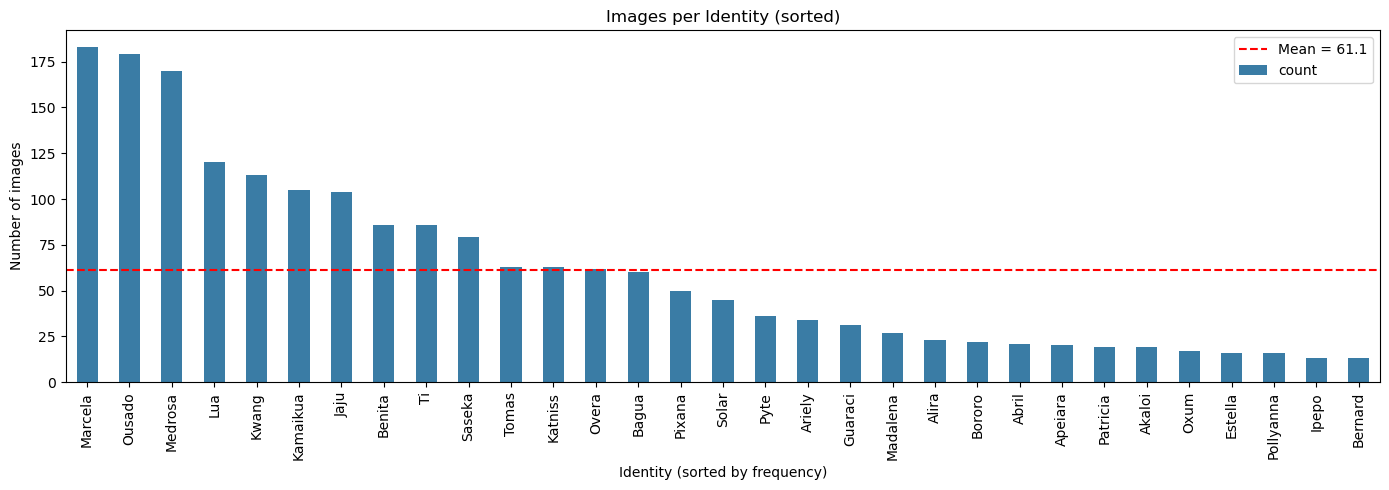

In [4]:
fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind="bar", ax=ax, color="#3A7CA5")
ax.set_title("Images per Identity (sorted)")
ax.set_xlabel("Identity (sorted by frequency)")
ax.set_ylabel("Number of images")
ax.axhline(identity_counts.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Mean = {identity_counts.mean():.1f}")
ax.legend()
plt.tight_layout()
plt.show()


## Experiment: Balanced Sampler vs Baseline Sampler


In [5]:
train_df_encoded, label_encoder = data.encode_labels(train_df)
train_data, val_data = data.train_val_split(
    train_df_encoded,
    val_split=config["val_split"],
    seed=config["split_seed"],
    stratify_col="ground_truth",
)

num_classes = len(label_encoder.classes_)

backbone = build_backbone(config["backbone_name"], pretrained=True).to(device)
backbone.eval()
param_count_backbone = sum(p.numel() for p in backbone.parameters())
backbone_out_dim = getattr(backbone, "num_features", None)
if backbone_out_dim is None:
    raise ValueError("Backbone output dimension not found")

backbone_train_loader, backbone_val_loader = data.create_backbone_dataloaders(
    backbone,
    train_data,
    val_data,
    img_dir=config["data_dir"] / "train" / "train",
    input_size=config["input_size"],
    batch_size=config["batch_size"],
    num_workers=config["num_workers"],
)

cache_dir = config["embeddings_cache_dir"]
cache_dir.mkdir(exist_ok=True)
cache_key = f"{config['backbone_name'].replace(':', '_').replace('/', '_')}_{config['input_size']}"

train_cache = cache_dir / f"train_{cache_key}.npz"
val_cache = cache_dir / f"val_{cache_key}.npz"

train_embeddings, train_labels = feature_cache.get_or_create_embeddings(
    train_cache,
    backbone,
    backbone_train_loader,
    device,
)
val_embeddings, val_labels = feature_cache.get_or_create_embeddings(
    val_cache,
    backbone,
    backbone_val_loader,
    device,
)

print(f"Train embeddings: {train_embeddings.shape}")
print(f"Val embeddings: {val_embeddings.shape}")


Train embeddings: (1516, 1024)
Val embeddings: (379, 1024)


In [6]:
def train_arcface_variant(balanced_sampling: bool, seed: int, run_tag: str):
    set_seed(seed)

    train_loader, val_loader = data.create_embedding_dataloaders(
        train_embeddings,
        train_labels,
        val_embeddings,
        val_labels,
        batch_size=config["batch_size"],
        num_workers=0,
        balanced_sampling=balanced_sampling,
    )

    model = MetricLearningModel(
        input_dim=backbone_out_dim,
        num_classes=num_classes,
        embedding_dim=config["embedding_dim"],
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
        arcface_margin=config["arcface_margin"],
        scale=config["arcface_scale"],
        loss_name="arcface",
    ).to(device)

    param_count = sum(p.numel() for p in model.parameters())
    run_name = f"03-{run_tag}-seed{seed}"
    checkpoint_name = f"ArcFace_{run_tag}_seed{seed}.pth"
    checkpoint_path = config["checkpoint_dir"] / checkpoint_name

    run_config = dict(config)
    run_config["balanced_sampling"] = balanced_sampling
    run_config["seed"] = seed
    run_config["run_tag"] = run_tag

    wandb = wandb_utils.init_wandb(
        run_config,
        run_name=run_name,
        param_count=param_count,
        param_count_backbone=param_count_backbone,
    )

    criterion = torch.nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
    )

    results = fit_embeddings(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        config=config,
        device=device,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        label_encoder=label_encoder,
        wandb_run=wandb,
        checkpoint_name=checkpoint_name,
    )

    wandb.run.summary["best_val_mAP"] = results["best_map"]
    wandb.run.summary["best_epoch"] = results["best_epoch"]
    wandb.run.summary["total_epochs"] = results["epochs_ran"]

    return model, results, wandb, checkpoint_path, run_name


def compute_ap_per_identity_df(model):
    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        val_final_embeddings = model.get_embeddings(val_tensor).cpu().numpy()

    sim_matrix = val_final_embeddings @ val_final_embeddings.T
    np.fill_diagonal(sim_matrix, -1.0)

    labels = np.asarray(val_labels)
    identity_aps = {}

    for query_idx in range(len(labels)):
        query_label = labels[query_idx]

        is_match = (labels == query_label).astype(np.int32)
        is_match[query_idx] = 0

        n_pos = is_match.sum()
        if n_pos == 0:
            continue

        sorted_idx = np.argsort(-sim_matrix[query_idx])
        sorted_matches = is_match[sorted_idx]

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = float((precision_at_k * sorted_matches).sum() / n_pos)

        identity_aps.setdefault(query_label, []).append(ap)

    train_counts = train_data["ground_truth"].value_counts()
    val_counts = val_data["ground_truth"].value_counts()

    rows = []
    for label_idx, aps in identity_aps.items():
        identity_name = label_encoder.classes_[label_idx]
        rows.append(
            {
                "identity": identity_name,
                "label_idx": int(label_idx),
                "train_count": int(train_counts.get(identity_name, 0)),
                "val_count": int(val_counts.get(identity_name, 0)),
                "num_val_queries": int(len(aps)),
                "mean_ap": float(np.mean(aps)),
                "std_ap": float(np.std(aps)),
            }
        )

    return pd.DataFrame(rows)


In [ ]:
variants = [
    {"name": "no_balanced_sampler", "balanced_sampling": False},
    {"name": "balanced_sampler", "balanced_sampling": True},
]

run_rows = []
all_ap_rows = []

for variant in variants:
    for seed in config["training_seeds"]:
        run_name = variant["name"]
        print("=" * 90)
        print(f"Running {run_name} | seed={seed} | balanced_sampling={variant['balanced_sampling']}")

        model, train_results, wandb, checkpoint_path, full_run_name = train_arcface_variant(
            balanced_sampling=variant["balanced_sampling"],
            seed=seed,
            run_tag=run_name,
        )

        ap_df = compute_ap_per_identity_df(model)
        ap_df["variant"] = run_name
        ap_df["seed"] = seed
        all_ap_rows.append(ap_df)

        wandb_utils.log_checkpoint_artifact(
            wandb,
            checkpoint_path,
            artifact_name=full_run_name,
            description="ArcFace checkpoint for sampler ablation",
        )
        wandb.finish()

        run_rows.append(
            {
                "variant": run_name,
                "balanced_sampling": variant["balanced_sampling"],
                "seed": seed,
                "best_val_map": train_results["best_map"],
                "best_epoch": train_results["best_epoch"],
                "total_epochs": train_results["epochs_ran"],}
        )

run_df = pd.DataFrame(run_rows)
all_ap_df = pd.concat(all_ap_rows, ignore_index=True)

print("Per-run results")
display(run_df.sort_values(["variant", "seed"]))


## Aggregated Comparison Across Seeds


no_balanced_sampler
Identities with defined AP: 31
Identity-balanced mAP: 0.8628
Worst 10 identities by AP


,identity,label_idx,train_count,val_count,num_val_queries,mean_ap,std_ap
26,Ipepo,11,10,3,3,0.199886,0.226305
24,Pollyanna,25,13,3,3,0.336924,0.234905
30,Bernard,7,10,3,3,0.337225,0.234748
20,Bororo,8,18,4,4,0.503654,0.287462
22,Patricia,23,15,4,4,0.511255,0.286642
14,Pixana,24,40,10,10,0.658659,0.308570
16,Apeiara,3,16,4,4,0.699767,0.171956
12,Oxum,22,14,3,3,0.861111,0.196419
0,Marcela,18,147,36,36,0.894099,0.221227
18,Solar,28,36,9,9,0.907132,0.238743


balanced_sampler
Identities with defined AP: 31
Identity-balanced mAP: 0.8703
Worst 10 identities by AP


,identity,label_idx,train_count,val_count,num_val_queries,mean_ap,std_ap
24,Pollyanna,25,13,3,3,0.336723,0.234975
26,Ipepo,11,10,3,3,0.338157,0.234506
30,Bernard,7,10,3,3,0.360979,0.236683
20,Bororo,8,18,4,4,0.505785,0.286473
22,Patricia,23,15,4,4,0.514056,0.285921
16,Apeiara,3,16,4,4,0.726115,0.193460
14,Pixana,24,40,10,10,0.742107,0.284538
18,Solar,28,36,9,9,0.838122,0.289220
0,Marcela,18,147,36,36,0.883050,0.215258
15,Tomas,30,50,13,13,0.913031,0.197350


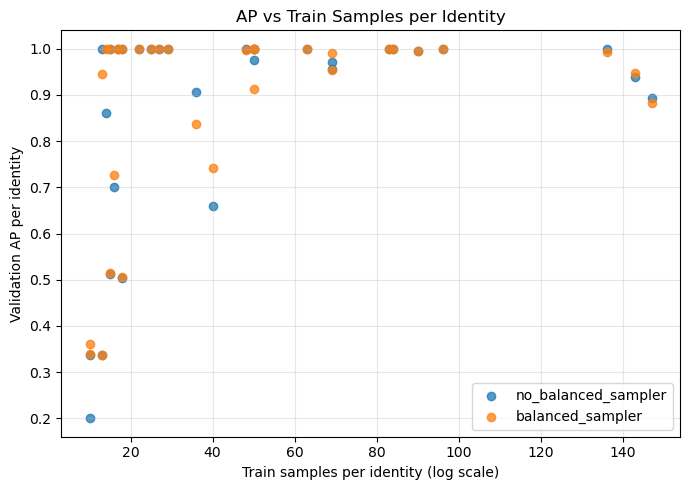

In [8]:
variant_summary = (
    run_df.groupby("variant", as_index=False)
    .agg(
        best_val_map_mean=("best_val_map", "mean"),
        best_val_map_std=("best_val_map", "std"),
        n_runs=("best_val_map", "count"),
    )
    .sort_values("best_val_map_mean", ascending=False)
)

print("Mean ± std of best validation mAP across seeds")
display(variant_summary)

identity_ap_summary = (
    all_ap_df.groupby(["variant", "identity", "train_count"], as_index=False)
    .agg(
        mean_ap=("mean_ap", "mean"),
        std_ap=("mean_ap", "std"),
    )
)

baseline_name = "no_balanced_sampler"
balanced_name = "balanced_sampler"

baseline_ap = identity_ap_summary[identity_ap_summary["variant"] == baseline_name][["identity", "train_count", "mean_ap"]].rename(columns={"mean_ap": "ap_baseline"})
balanced_ap = identity_ap_summary[identity_ap_summary["variant"] == balanced_name][["identity", "mean_ap"]].rename(columns={"mean_ap": "ap_balanced"})

ap_compare = baseline_ap.merge(balanced_ap, on="identity", how="inner")
ap_compare["ap_delta"] = ap_compare["ap_balanced"] - ap_compare["ap_baseline"]

identity_order = identity_counts.index.tolist()
ap_compare["identity"] = pd.Categorical(ap_compare["identity"], categories=identity_order, ordered=True)
ap_compare = ap_compare.sort_values("identity")

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(ap_compare["identity"].astype(str), ap_compare["ap_delta"], color="#3A7CA5")
ax.axhline(0.0, color="black", linewidth=1)
ax.set_title("Per-Identity AP Delta (Balanced Sampler - Baseline)")
ax.set_xlabel("Identity")
ax.set_ylabel("AP Delta")
ax.tick_params(axis="x", rotation=90)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

largest_gains = ap_compare.sort_values("ap_delta", ascending=False).head(5)
largest_drops = ap_compare.sort_values("ap_delta", ascending=True).head(5)

print("Top 5 identity AP improvements")
display(largest_gains[["identity", "train_count", "ap_baseline", "ap_balanced", "ap_delta"]])

print("Top 5 identity AP decreases")
display(largest_drops[["identity", "train_count", "ap_baseline", "ap_balanced", "ap_delta"]])
